In [10]:
import numpy as np
import matplotlib.pyplot as plt
import jax.random as jrd
from evoscape.landscapes import Landscape
from evoscape.modules import Node, UnstableNode
from evoscape.landscape_visuals import *
from jax_test import pytree_to_landscape,  regimes
from jax_test.regimes import mr_const
from jax_test.dynamics import get_cell_states
from jax_test.losses import origin_leading_fitness
from jax_test.experiment import run_experiment
plt.style.use('default')
plt.rcParams.update({'figure.dpi': 100})
plt.rcParams.update({'font.size': 15})

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# Landscape with one regime + simple visualization
%autoreload

# Definition of the modules of the landscape: to be constructed accordingly
M1 = Node(x=-1.5, y=0., a=1.5, s=1.)
M2 = Node(x=1.5, y=0., a=2., s=0.8)
M3 = UnstableNode(x=0., y=1., a=1.3, s=0.8)

module_list = [M1, M2, M3]

for M in module_list:
    print(M)

# Definition of the landscape
landscape = Landscape(module_list, A0 = 0.05, regime=mr_const, n_regimes=1)
print(landscape)

# Parameters of vizualisation 
L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')


# key used for noise
key = jrd.PRNGKey(0)

#Numerical constants for simulation
n, t0,tf, nt, ndt, noise, η, iterations=100, 0., 10., 51, 50, 0.2, 1, 500

# Selection of the get_states function 
get_states = get_cell_states

# Selection of the fitness function
loss_function = origin_leading_fitness

loss_param = None

# For signal regime
signal_param = None

Node: x=-1.5; y=0.0; a=1.5; s=1.
Node: x=1.5; y=0.0; a=2.; s=0.8
UnstableNode: x=0.0; y=1.0; a=1.3; s=0.8
Landscape with modules:
Node: x=-1.5; y=0.0; a=1.5; s=1.,
Node: x=1.5; y=0.0; a=2.; s=0.8,
UnstableNode: x=0.0; y=1.0; a=1.3; s=0.8


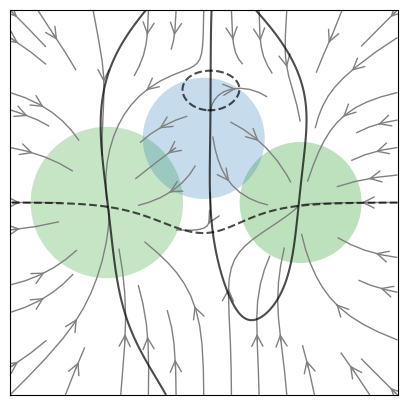

In [12]:
fig = visualize_landscape(landscape, xx, yy, regime=0, color_scheme='fp_types')

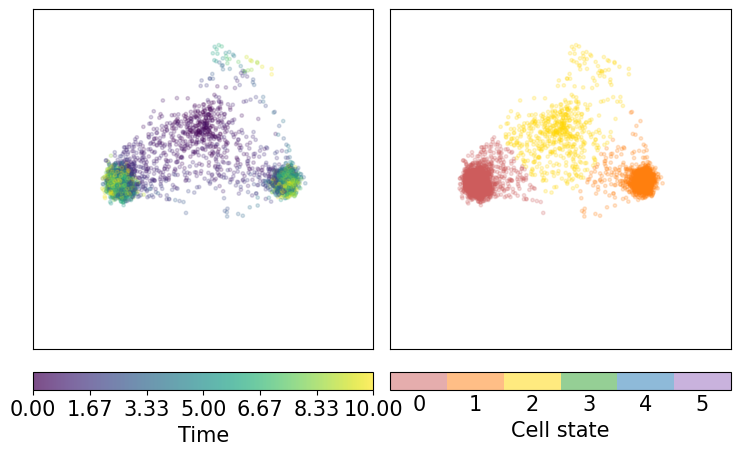

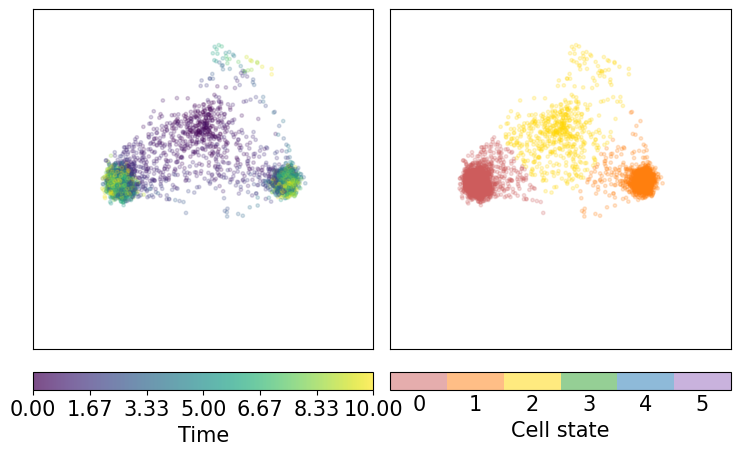

In [13]:
landscape.init_cells(n,landscape.init_cond,noise=noise)
get_and_plot_traj(landscape,t0,tf,nt,L,noise)

In [14]:
dynamic, static, losses, traj, states= run_experiment(
    landscape,
    key,
    n,
    t0,
    tf,
    nt,
    ndt,
    noise,
    iterations,
    η,
    get_states,
    loss_function,
    loss_param,
    signal_param
    )


In [15]:
print(dynamic)

LandscapeDynamic(init_cond=Array([0.00283953, 0.9993735 ], dtype=float32), module=ModuleDynamic(x=Array([-0.00386652,  0.00667472,  0.23567827], dtype=float32), y=Array([0.0800895 , 0.06923968, 1.7997983 ], dtype=float32), a=Array([2.5968015, 2.9076853, 1.0386422], dtype=float32), s=Array([1.250761 , 1.1173434, 1.       ], dtype=float32)))


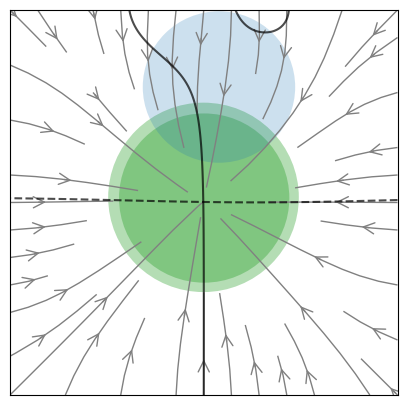

In [16]:
l = pytree_to_landscape(dynamic=dynamic,static=static,trajectories=np.array(traj), cell_states= np.array(states), cell_coordinates= np.array(traj[:,:,-1]))
fig = visualize_landscape(l, xx, yy, regime=0, color_scheme='fp_types')

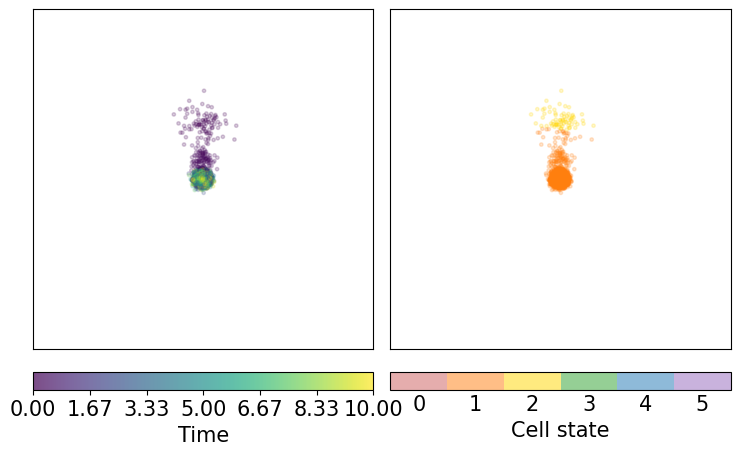

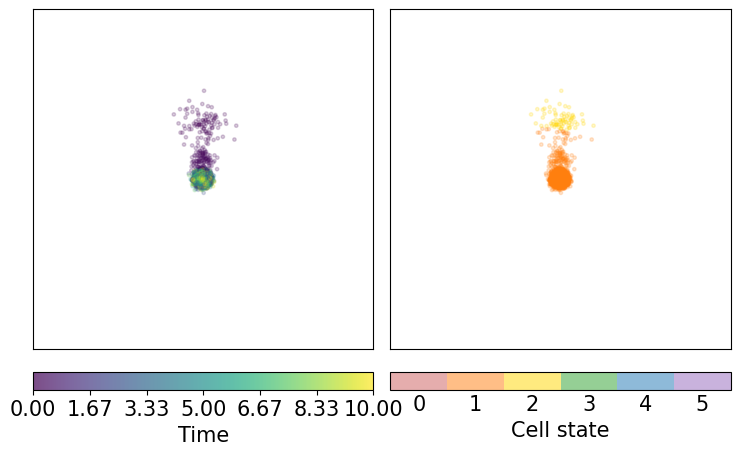

In [17]:
# Put back the coordinates of the cells at the init_ as the are
l.init_cells(n,dynamic.init_cond,noise=noise)
get_and_plot_traj(l,t0,tf,nt,L,noise)

In [18]:
n_frames = 100
time_pars = (t0,tf, n_frames)
print(l.n_regimes)
labels = [f"regime {i}" for i in range(0,l.n_regimes+1)]
print(labels)
make_movie_discrete(l, xx, yy, labels, time_pars, n, noise, init_cond=l.init_cond,
                        circles=True, circle_opacity=0.1, density=0.65, nullclines=False,
                        fps=10, save_dir='../figures/', filename='movie.gif')

save_dir = '../figures/'
import os, glob
for f in glob.glob(save_dir + "frame_*.png"):
    os.remove(f)

1
['regime 0', 'regime 1']
Movie saved to ../figures/movie.gif
